# Machine Learning-Based Cyber Threat Detection and Cross-Dataset Network Traffic Analysis for Enhanced Intrusion Detection


## Import Required Libraries

In [1]:
# Core data handling libraries
import pandas as pd
import numpy as np

# Visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Evaluation metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)

# ML models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Warnings and display settings
import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 100)

## Dataset Loading

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!unzip /content/drive/MyDrive/data.zip

Archive:  /content/drive/MyDrive/data.zip
   creating: data/
   creating: data/CICIDS2017/
  inflating: data/CICIDS2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv  
  inflating: data/CICIDS2017/Monday-WorkingHours.pcap_ISCX.csv  
  inflating: data/CICIDS2017/Tuesday-WorkingHours.pcap_ISCX.csv  
  inflating: data/CICIDS2017/Wednesday-workingHours.pcap_ISCX.csv  
   creating: data/CICIDS2018/
  inflating: data/CICIDS2018/DDOS attack-HOIC.csv  
  inflating: data/CICIDS2018/DoS attacks-Hulk.csv  
  inflating: data/CICIDS2018/FTP-BruteForce.csv  


In [4]:
# Folder paths
PATH_2017 = "./data/CICIDS2017/"
PATH_2018 = "./data/CICIDS2018/"

# List of CIC-IDS2017 files
files_2017 = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"
]

# List of CIC-IDS2018 files
files_2018 = [
    "FTP-BruteForce.csv",
    "DoS attacks-Hulk.csv",
    "DDOS attack-HOIC.csv"
]

In [5]:
# Number of rows to sample per file
SAMPLE_ROWS_PER_FILE = 60000
RANDOM_STATE = 42

In [6]:
# Load and sample each CIC-IDS2017 file, then combine into one dataframe
df_2017_list = []
for file_name in files_2017:
    file_path = PATH_2017 + file_name
    temp_df = pd.read_csv(file_path, low_memory=False)
    temp_df.columns = temp_df.columns.str.strip()
    if len(temp_df) > SAMPLE_ROWS_PER_FILE:
        temp_df = temp_df.sample(n=SAMPLE_ROWS_PER_FILE, random_state=RANDOM_STATE)
    df_2017_list.append(temp_df)

df_2017 = pd.concat(df_2017_list, ignore_index=True)
print("CIC-IDS2017 combined shape:", df_2017.shape)

CIC-IDS2017 combined shape: (240000, 79)


In [7]:
# Load and sample each CIC-IDS2018 file, then combine into one dataframe
df_2018_list = []
for file_name in files_2018:
    file_path = PATH_2018 + file_name
    temp_df = pd.read_csv(file_path, low_memory=False)
    temp_df.columns = temp_df.columns.str.strip()
    if len(temp_df) > SAMPLE_ROWS_PER_FILE:
        temp_df = temp_df.sample(n=SAMPLE_ROWS_PER_FILE, random_state=RANDOM_STATE)
    df_2018_list.append(temp_df)

df_2018 = pd.concat(df_2018_list, ignore_index=True)
print("CIC-IDS2018 combined shape:", df_2018.shape)

CIC-IDS2018 combined shape: (180000, 79)


## Data Inspection

In [8]:
# First 5 rows of CIC-IDS2017
df_2017.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,5271779,3,1,12,0,6,0,4.000000,3.464102,0,0,0.0,0.000000,2.276271,0.758757,1.757260e+06,2.949657e+06,5162649,95,5271779,2.635890e+06,3.573378e+06,5162649,109130,0,0.000000e+00,0.000000,0,0,0,0,0,0,72,32,0.569068,0.189689,0,6,2.400000,3.286335,10.800000,0,0,0,1,0,0,0,0,0,3.000000,4.000000,0.0,72,0,0,0,0,0,0,3,12,1,0,8192,29200,2,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,443,153756,10,5,1140,943,901,0,114.000000,280.179308,805,0,188.6,349.721032,13547.438799,97.557169,1.098257e+04,1.723219e+04,42224,4,153756,1.708400e+04,2.201691e+04,52270,4,97563,2.439075e+04,22055.660488,43481,280,0,0,0,0,332,168,65.038112,32.519056,0,901,130.187500,286.630126,82156.829167,0,0,0,1,0,0,0,0,0,138.866667,114.000000,188.6,332,0,0,0,0,0,0,10,1140,5,943,65535,362,5,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,443,312614,15,10,974,7387,469,0,64.933333,134.265976,1581,0,738.7,750.412931,26745.443262,79.970827,1.302558e+04,2.341654e+04,75965,1,312614,2.232957e+04,2.765258e+04,76628,1,236590,2.628778e+04,40432.702760,98944,1,0,0,0,0,492,328,47.982496,31.988331,0,1581,321.576923,571.026316,326071.053846,0,0,0,1,0,0,0,0,0,334.440000,64.933333,738.7,492,0,0,0,0,0,0,15,974,10,7387,65535,357,6,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,53,62774,2,2,64,200,32,32,32.000000,0.000000,100,100,100.0,0.000000,4205.562813,63.720649,2.092467e+04,3.620016e+04,62725,1,1,1.000000e+00,0.000000e+00,1,1,48,4.800000e+01,0.000000,48,48,0,0,0,0,40,80,31.860324,31.860324,32,100,59.200000,37.245134,1387.200000,0,0,0,0,0,0,0,0,1,74.000000,32.000000,100.0,40,0,0,0,0,0,0,2,64,2,200,-1,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,123,68044766,2,2,96,96,48,48,48.000000,0.000000,48,48,48.0,0.000000,2.821672,0.058785,2.268159e+07,3.920843e+07,67955579,44475,68000054,6.800005e+07,0.000000e+00,68000054,68000054,68000291,6.800029e+07,0.000000,68000291,68000291,0,0,0,0,40,40,0.029392,0.029392,48,48,48.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,1,60.000000,48.000000,48.0,40,0,0,0,0,0,0,2,96,2,96,-1,-1,1,20,44475.0,0.0,44475,44475,67955579.0,0.0,67955579,67955579,BENIGN


In [9]:
# Data types and non-null counts for CIC-IDS2017
df_2017.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240000 entries, 0 to 239999
Data columns (total 79 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Destination Port             240000 non-null  int64  
 1   Flow Duration                240000 non-null  int64  
 2   Total Fwd Packets            240000 non-null  int64  
 3   Total Backward Packets       240000 non-null  int64  
 4   Total Length of Fwd Packets  240000 non-null  int64  
 5   Total Length of Bwd Packets  240000 non-null  int64  
 6   Fwd Packet Length Max        240000 non-null  int64  
 7   Fwd Packet Length Min        240000 non-null  int64  
 8   Fwd Packet Length Mean       240000 non-null  float64
 9   Fwd Packet Length Std        240000 non-null  float64
 10  Bwd Packet Length Max        240000 non-null  int64  
 11  Bwd Packet Length Min        240000 non-null  int64  
 12  Bwd Packet Length Mean       240000 non-null  float64
 13 

In [10]:
# Statistical summary of numeric columns in CIC-IDS2017
df_2017.describe().T

,count,mean,std,min,25%,50%,75%,max
Destination Port,240000.0,8.535453e+03,1.931004e+04,0.0,53.0,80.0,443.00,6.553200e+04
Flow Duration,240000.0,1.626132e+07,3.429037e+07,-1.0,228.0,68220.0,5751808.25,1.200000e+08
Total Fwd Packets,240000.0,9.535479e+00,7.397017e+02,1.0,2.0,2.0,5.00,1.932000e+05
Total Backward Packets,240000.0,1.053960e+01,9.753944e+02,0.0,1.0,2.0,5.00,2.567400e+05
Total Length of Fwd Packets,240000.0,6.417176e+02,5.313109e+03,0.0,24.0,60.0,271.00,1.162781e+06
...,...,...,...,...,...,...,...,...
Active Min,240000.0,8.408207e+04,6.711328e+05,0.0,0.0,0.0,0.00,1.070000e+08
Idle Mean,240000.0,9.716068e+06,2.485417e+07,0.0,0.0,0.0,0.00,1.200000e+08
Idle Std,240000.0,1.109044e+06,7.077450e+06,0.0,0.0,0.0,0.00,7.514502e+07
Idle Max,240000.0,1.052416e+07,2.636216e+07,0.0,0.0,0.0,0.00,1.200000e+08


In [11]:
# Class distribution in CIC-IDS2017 (raw attack labels)
df_2017["Label"].value_counts()

,count
Label,
BENIGN,182275
DDoS,34120
DoS Hulk,19937
FTP-Patator,1056
DoS GoldenEye,851
SSH-Patator,792
DoS Slowhttptest,484
DoS slowloris,483
Heartbleed,2


In [12]:
# Class distribution in CIC-IDS2018 (raw attack labels)
df_2018["Label"].value_counts()

,count
Label,
Benign,126944
DoS attacks-Hulk,17755
DDOS attack-HOIC,17720
FTP-BruteForce,17581


In [13]:
# Check for missing values in CIC-IDS2017
df_2017.isnull().sum().sort_values(ascending=False).head(10)

,0
Flow Bytes/s,107
Flow Duration,0
Destination Port,0
Total Backward Packets,0
Total Length of Fwd Packets,0
Total Length of Bwd Packets,0
Total Fwd Packets,0
Fwd Packet Length Max,0
Fwd Packet Length Min,0
Fwd Packet Length Std,0


In [14]:
# Check for infinite values in CIC-IDS2017 numeric columns
np.isinf(df_2017.select_dtypes(include=[np.number])).sum().sort_values(ascending=False).head(10)

,0
Flow Packets/s,181
Flow Bytes/s,74
Total Fwd Packets,0
Total Backward Packets,0
Destination Port,0
Flow Duration,0
Fwd Packet Length Max,0
Fwd Packet Length Min,0
Fwd Packet Length Mean,0
Fwd Packet Length Std,0


## Data Processing


In [15]:
# Rename map: CIC-IDS2018 abbreviated column names -> CIC-IDS2017 full column names
column_rename_map = {
    "Dst Port": "Destination Port", "Tot Fwd Pkts": "Total Fwd Packets",
    "Tot Bwd Pkts": "Total Backward Packets", "TotLen Fwd Pkts": "Total Length of Fwd Packets",
    "TotLen Bwd Pkts": "Total Length of Bwd Packets", "Fwd Pkt Len Max": "Fwd Packet Length Max",
    "Fwd Pkt Len Min": "Fwd Packet Length Min", "Fwd Pkt Len Mean": "Fwd Packet Length Mean",
    "Fwd Pkt Len Std": "Fwd Packet Length Std", "Bwd Pkt Len Max": "Bwd Packet Length Max",
    "Bwd Pkt Len Min": "Bwd Packet Length Min", "Bwd Pkt Len Mean": "Bwd Packet Length Mean",
    "Bwd Pkt Len Std": "Bwd Packet Length Std", "Flow Byts/s": "Flow Bytes/s",
    "Flow Pkts/s": "Flow Packets/s", "Fwd IAT Tot": "Fwd IAT Total",
    "Bwd IAT Tot": "Bwd IAT Total", "Fwd Header Len": "Fwd Header Length",
    "Bwd Header Len": "Bwd Header Length", "Fwd Pkts/s": "Fwd Packets/s",
    "Bwd Pkts/s": "Bwd Packets/s", "Pkt Len Min": "Min Packet Length",
    "Pkt Len Max": "Max Packet Length", "Pkt Len Mean": "Packet Length Mean",
    "Pkt Len Std": "Packet Length Std", "Pkt Len Var": "Packet Length Variance",
    "FIN Flag Cnt": "FIN Flag Count", "SYN Flag Cnt": "SYN Flag Count",
    "RST Flag Cnt": "RST Flag Count", "PSH Flag Cnt": "PSH Flag Count",
    "ACK Flag Cnt": "ACK Flag Count", "URG Flag Cnt": "URG Flag Count",
    "ECE Flag Cnt": "ECE Flag Count", "Pkt Size Avg": "Average Packet Size",
    "Fwd Seg Size Avg": "Avg Fwd Segment Size", "Bwd Seg Size Avg": "Avg Bwd Segment Size",
    "Subflow Fwd Pkts": "Subflow Fwd Packets", "Subflow Fwd Byts": "Subflow Fwd Bytes",
    "Subflow Bwd Pkts": "Subflow Bwd Packets", "Subflow Bwd Byts": "Subflow Bwd Bytes",
    "Init Fwd Win Byts": "Init_Win_bytes_forward", "Init Bwd Win Byts": "Init_Win_bytes_backward",
    "Fwd Act Data Pkts": "act_data_pkt_fwd", "Fwd Seg Size Min": "min_seg_size_forward"
}

# Apply rename map to CIC-IDS2018 dataframe
df_2018 = df_2018.rename(columns=column_rename_map)

In [16]:
# Identify feature columns common to both datasets
non_feature_cols = ["Flow ID", "Src IP", "Source IP", "Dst IP", "Destination IP",
                     "Src Port", "Source Port", "Timestamp", "Protocol"]

common_columns = [col for col in df_2017.columns if col in df_2018.columns and col not in non_feature_cols]
print("Number of common feature columns (incl. Label):", len(common_columns))

Number of common feature columns (incl. Label): 72


In [17]:
# Restrict both dataframes to the shared column set
df_2017 = df_2017[common_columns].copy()
df_2018 = df_2018[common_columns].copy()
print("CIC-IDS2017 shape after alignment:", df_2017.shape)
print("CIC-IDS2018 shape after alignment:", df_2018.shape)

CIC-IDS2017 shape after alignment: (240000, 72)
CIC-IDS2018 shape after alignment: (180000, 72)


In [18]:
# Replace infinite values with NaN, then drop rows containing NaN (CIC-IDS2017)
df_2017 = df_2017.replace([np.inf, -np.inf], np.nan)
df_2017 = df_2017.dropna()

# Replace infinite values with NaN, then drop rows containing NaN (CIC-IDS2018)
df_2018 = df_2018.replace([np.inf, -np.inf], np.nan)
df_2018 = df_2018.dropna()

print("CIC-IDS2017 shape after cleaning:", df_2017.shape)
print("CIC-IDS2018 shape after cleaning:", df_2018.shape)

CIC-IDS2017 shape after cleaning: (239819, 72)
CIC-IDS2018 shape after cleaning: (180000, 72)


In [19]:
# Remove duplicate rows from both datasets
df_2017 = df_2017.drop_duplicates()
df_2018 = df_2018.drop_duplicates()

print("CIC-IDS2017 shape after removing duplicates:", df_2017.shape)
print("CIC-IDS2018 shape after removing duplicates:", df_2018.shape)

CIC-IDS2017 shape after removing duplicates: (230596, 72)
CIC-IDS2018 shape after removing duplicates: (147299, 72)


In [20]:
# Create a binary label: BENIGN = 0, any attack = 1 (CIC-IDS2017)
df_2017["Binary_Label"] = df_2017["Label"].apply(lambda x: 0 if x.strip().upper() == "BENIGN" else 1)

# Create a binary label: BENIGN = 0, any attack = 1 (CIC-IDS2018)
df_2018["Binary_Label"] = df_2018["Label"].apply(lambda x: 0 if x.strip().upper() == "BENIGN" else 1)

print("CIC-IDS2017 binary label counts:\n", df_2017["Binary_Label"].value_counts())
print("CIC-IDS2018 binary label counts:\n", df_2018["Binary_Label"].value_counts())

CIC-IDS2017 binary label counts:
 Binary_Label
0    177940
1     52656
Name: count, dtype: int64
CIC-IDS2018 binary label counts:
 Binary_Label
0    120266
1     27033
Name: count, dtype: int64


## Exploratory Data Analysis (EDA)

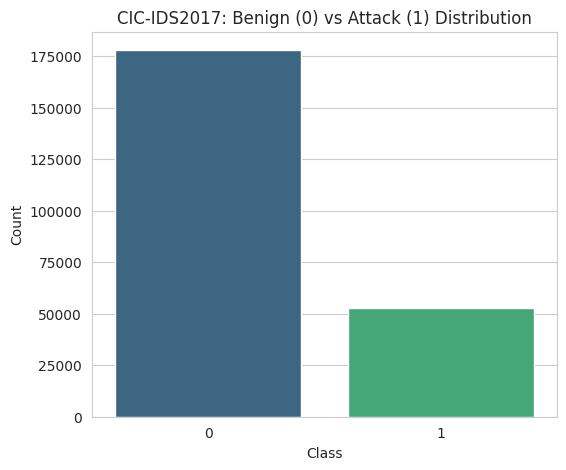

In [21]:
# Graph 1: Binary label distribution in CIC-IDS2017 (Benign vs Attack)
plt.figure(figsize=(6, 5))
sns.countplot(x="Binary_Label", data=df_2017, palette="viridis")
plt.title("CIC-IDS2017: Benign (0) vs Attack (1) Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

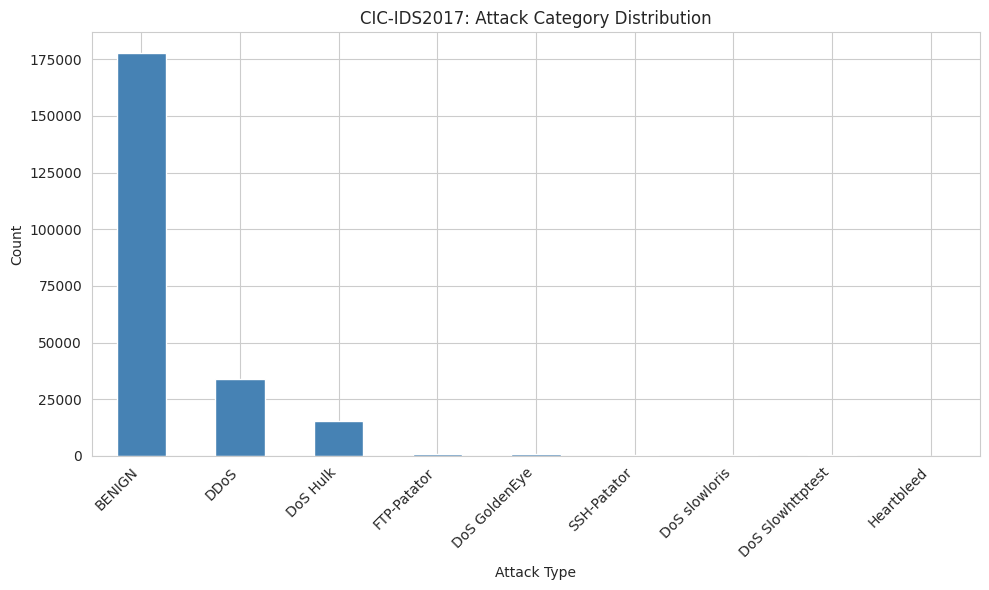

In [22]:
# Graph 2: Attack category distribution in CIC-IDS2017 (multiclass label)
plt.figure(figsize=(10, 6))
df_2017["Label"].value_counts().plot(kind="bar", color="steelblue")
plt.title("CIC-IDS2017: Attack Category Distribution")
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

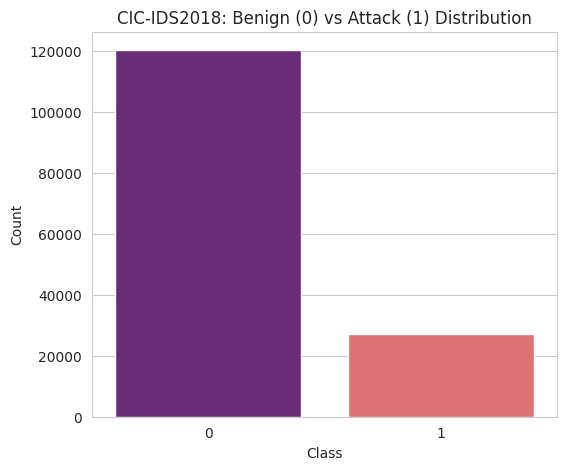

In [23]:
# Graph 3: Binary label distribution in CIC-IDS2018 (Benign vs Attack)
plt.figure(figsize=(6, 5))
sns.countplot(x="Binary_Label", data=df_2018, palette="magma")
plt.title("CIC-IDS2018: Benign (0) vs Attack (1) Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

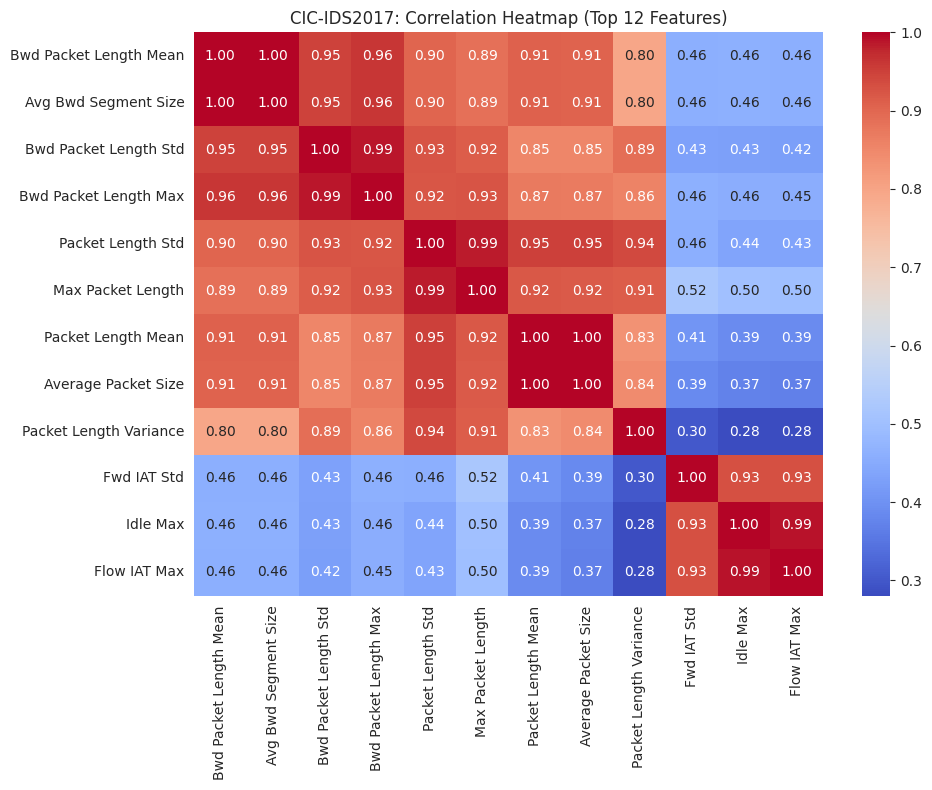

In [24]:
# Graph 4: Correlation heatmap of top numeric features in CIC-IDS2017
numeric_cols_2017 = df_2017.select_dtypes(include=[np.number]).drop(columns=["Binary_Label"])
top_corr_features = numeric_cols_2017.corrwith(df_2017["Binary_Label"]).abs().sort_values(ascending=False).head(12).index

plt.figure(figsize=(10, 8))
sns.heatmap(df_2017[top_corr_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("CIC-IDS2017: Correlation Heatmap (Top 12 Features)")
plt.tight_layout()
plt.show()

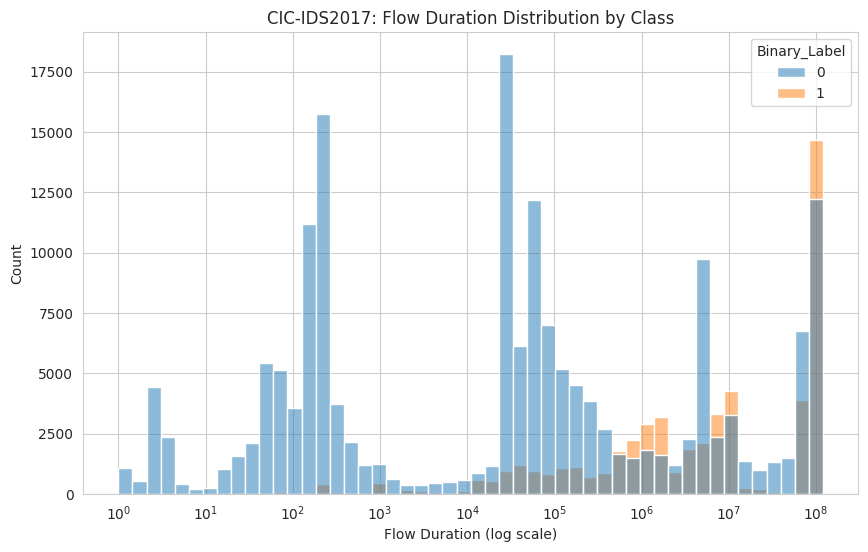

In [25]:
# Graph 5: Flow Duration distribution by class (CIC-IDS2017)
plt.figure(figsize=(10, 6))
sns.histplot(data=df_2017, x="Flow Duration", hue="Binary_Label", bins=50, log_scale=(True, False))
plt.title("CIC-IDS2017: Flow Duration Distribution by Class")
plt.xlabel("Flow Duration (log scale)")
plt.show()

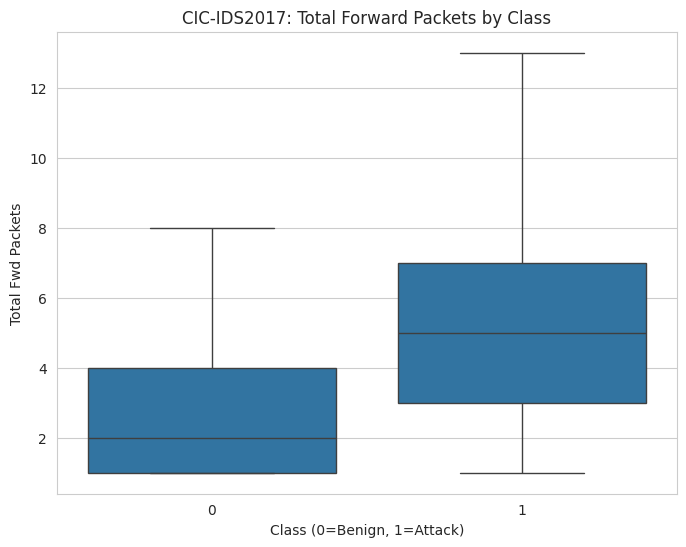

In [26]:
# Graph 6: Boxplot of Total Fwd Packets by class (CIC-IDS2017)
plt.figure(figsize=(8, 6))
sns.boxplot(x="Binary_Label", y="Total Fwd Packets", data=df_2017, showfliers=False)
plt.title("CIC-IDS2017: Total Forward Packets by Class")
plt.xlabel("Class (0=Benign, 1=Attack)")
plt.show()

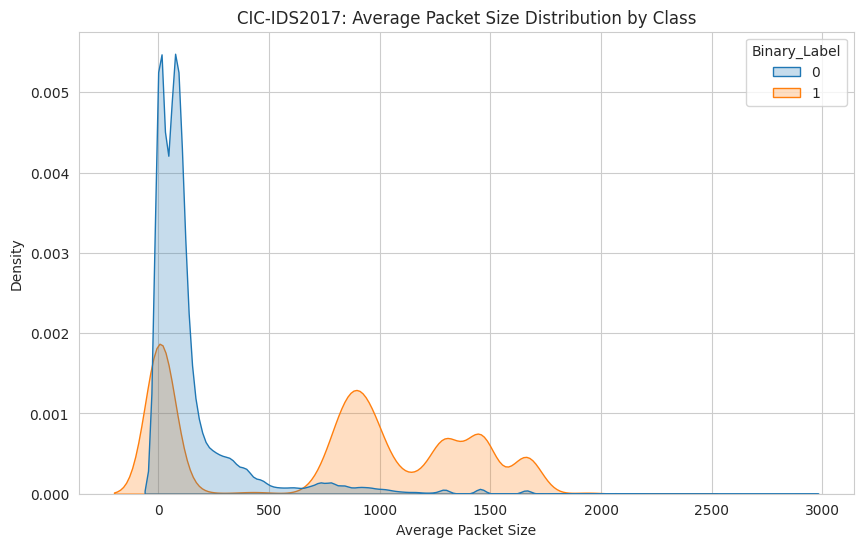

In [27]:
# Graph 7: Average Packet Size distribution (CIC-IDS2017)
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_2017, x="Average Packet Size", hue="Binary_Label", fill=True, common_norm=False)
plt.title("CIC-IDS2017: Average Packet Size Distribution by Class")
plt.show()

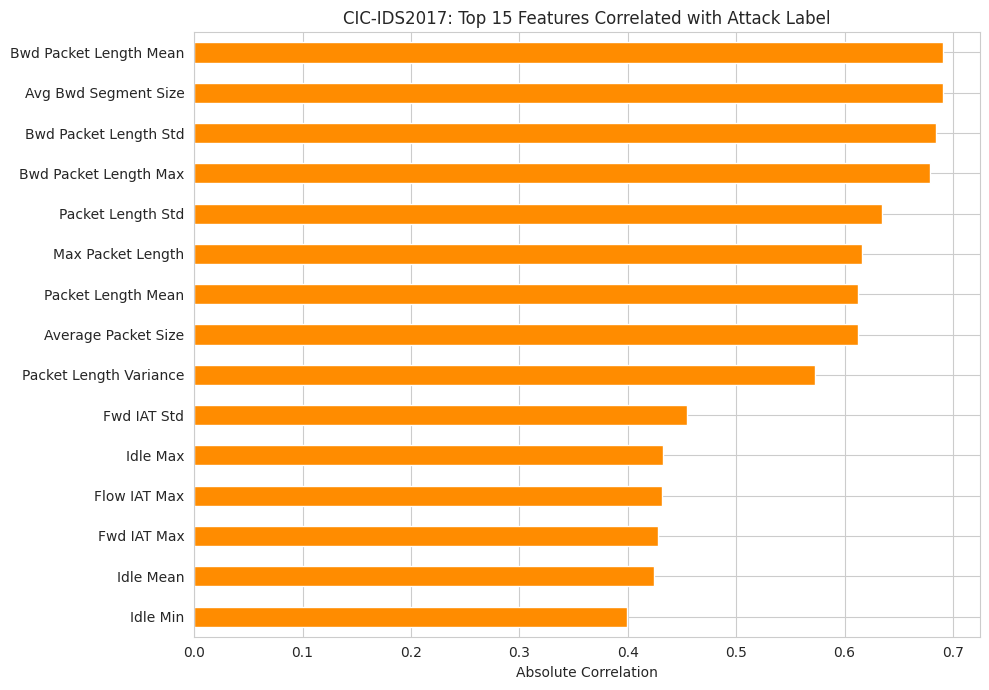

In [28]:
# Graph 8: Top 15 features most correlated with Binary_Label (CIC-IDS2017)
top15_corr = numeric_cols_2017.corrwith(df_2017["Binary_Label"]).abs().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 7))
top15_corr.plot(kind="barh", color="darkorange")
plt.title("CIC-IDS2017: Top 15 Features Correlated with Attack Label")
plt.xlabel("Absolute Correlation")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Data Pre-processing and Feature Engineering for ML Models

In [29]:
# Select the top 20 features most correlated with the binary label (feature selection)
selected_features = numeric_cols_2017.corrwith(df_2017["Binary_Label"]).abs().sort_values(ascending=False).head(20).index.tolist()
print("Selected features:\n", selected_features)

Selected features:
 ['Bwd Packet Length Mean', 'Avg Bwd Segment Size', 'Bwd Packet Length Std', 'Bwd Packet Length Max', 'Packet Length Std', 'Max Packet Length', 'Packet Length Mean', 'Average Packet Size', 'Packet Length Variance', 'Fwd IAT Std', 'Idle Max', 'Flow IAT Max', 'Fwd IAT Max', 'Idle Mean', 'Idle Min', 'Flow IAT Std', 'Min Packet Length', 'Bwd Packet Length Min', 'Fwd IAT Total', 'Flow Duration']


In [30]:
# Build feature matrix (X) and target vector (y) for CIC-IDS2017
X_2017 = df_2017[selected_features]
y_2017 = df_2017["Binary_Label"]

# Build feature matrix (X) and target vector (y) for CIC-IDS2018
X_2018 = df_2018[selected_features]
y_2018 = df_2018["Binary_Label"]

In [31]:
# Train/test split on CIC-IDS2017 (80% train, 20% baseline test)
X_train, X_test, y_train, y_test = train_test_split(
    X_2017, y_2017, test_size=0.2, random_state=RANDOM_STATE, stratify=y_2017
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (184476, 20)  Test shape: (46120, 20)


In [32]:
# Fit StandardScaler on CIC-IDS2017 training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Transform the CIC-IDS2017 baseline test set using the same fitted scaler
X_test_scaled = scaler.transform(X_test)

In [33]:
# Transform the full CIC-IDS2018 dataset using the scaler fitted on CIC-IDS2017 (cross-dataset use)
X_2018_scaled = scaler.transform(X_2018)

In [34]:
# Split CIC-IDS2018 into a 10% fine-tuning set and a 90% held-out cross-dataset test set
X_2018_finetune, X_2018_holdout, y_2018_finetune, y_2018_holdout = train_test_split(
    X_2018_scaled, y_2018, test_size=0.9, random_state=RANDOM_STATE, stratify=y_2018
)
print("Fine-tune set shape:", X_2018_finetune.shape, " Holdout set shape:", X_2018_holdout.shape)

Fine-tune set shape: (14729, 20)  Holdout set shape: (132570, 20)


## Machine Learning Models

### Random Forest

In [35]:
# Initialise Random Forest model
rf_model = RandomForestClassifier(n_estimators=150, max_depth=15, random_state=RANDOM_STATE,
                                   n_jobs=-1, warm_start=True)

In [36]:
# Train Random Forest on CIC-IDS2017 training data
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(max_depth=15, n_estimators=150, n_jobs=-1,
                       random_state=42, warm_start=True)

In [37]:
# Predict on CIC-IDS2017 baseline test set
rf_pred_baseline = rf_model.predict(X_test_scaled)
rf_proba_baseline = rf_model.predict_proba(X_test_scaled)[:, 1]

In [38]:
# Evaluate Random Forest baseline performance on CIC-IDS2017
rf_baseline_acc = accuracy_score(y_test, rf_pred_baseline)
rf_baseline_prec = precision_score(y_test, rf_pred_baseline)
rf_baseline_rec = recall_score(y_test, rf_pred_baseline)
rf_baseline_f1 = f1_score(y_test, rf_pred_baseline)
rf_baseline_auc = roc_auc_score(y_test, rf_proba_baseline)

print("Random Forest Baseline (2017) - Accuracy:", round(rf_baseline_acc, 4))
print("Precision:", round(rf_baseline_prec, 4), " Recall:", round(rf_baseline_rec, 4),
      " F1:", round(rf_baseline_f1, 4), " ROC-AUC:", round(rf_baseline_auc, 4))
print(confusion_matrix(y_test, rf_pred_baseline))

Random Forest Baseline (2017) - Accuracy: 0.9966
Precision: 0.9956  Recall: 0.9894  F1: 0.9925  ROC-AUC: 0.9997
[[35543    46]
 [  112 10419]]


In [39]:
# Predict directly on CIC-IDS2018 holdout set using the model trained only on CIC-IDS2017 (cross-dataset)
rf_pred_cross = rf_model.predict(X_2018_holdout)
rf_proba_cross = rf_model.predict_proba(X_2018_holdout)[:, 1]

In [40]:
# Evaluate Random Forest cross-dataset performance on CIC-IDS2018 (before fine-tuning)
rf_cross_acc = accuracy_score(y_2018_holdout, rf_pred_cross)
rf_cross_prec = precision_score(y_2018_holdout, rf_pred_cross)
rf_cross_rec = recall_score(y_2018_holdout, rf_pred_cross)
rf_cross_f1 = f1_score(y_2018_holdout, rf_pred_cross)
rf_cross_auc = roc_auc_score(y_2018_holdout, rf_proba_cross)

print("Random Forest Cross-Dataset (2018, no fine-tune) - Accuracy:", round(rf_cross_acc, 4))
print("Precision:", round(rf_cross_prec, 4), " Recall:", round(rf_cross_rec, 4),
      " F1:", round(rf_cross_f1, 4), " ROC-AUC:", round(rf_cross_auc, 4))

Random Forest Cross-Dataset (2018, no fine-tune) - Accuracy: 0.7839
Precision: 0.0403  Recall: 0.0078  F1: 0.013  ROC-AUC: 0.7704


In [41]:
# Fine-tune Random Forest by adding extra trees trained on 10% of CIC-IDS2018
rf_model.n_estimators += 50
rf_model.fit(X_2018_finetune, y_2018_finetune)

RandomForestClassifier(max_depth=15, n_estimators=200, n_jobs=-1,
                       random_state=42, warm_start=True)

In [42]:
# Predict on the remaining 90% of CIC-IDS2018 after fine-tuning
rf_pred_finetuned = rf_model.predict(X_2018_holdout)
rf_proba_finetuned = rf_model.predict_proba(X_2018_holdout)[:, 1]

In [43]:
# Evaluate Random Forest fine-tuned performance on CIC-IDS2018 holdout set
rf_ft_acc = accuracy_score(y_2018_holdout, rf_pred_finetuned)
rf_ft_prec = precision_score(y_2018_holdout, rf_pred_finetuned)
rf_ft_rec = recall_score(y_2018_holdout, rf_pred_finetuned)
rf_ft_f1 = f1_score(y_2018_holdout, rf_pred_finetuned)
rf_ft_auc = roc_auc_score(y_2018_holdout, rf_proba_finetuned)

print("Random Forest Fine-Tuned (2018) - Accuracy:", round(rf_ft_acc, 4))
print("Precision:", round(rf_ft_prec, 4), " Recall:", round(rf_ft_rec, 4),
      " F1:", round(rf_ft_f1, 4), " ROC-AUC:", round(rf_ft_auc, 4))

Random Forest Fine-Tuned (2018) - Accuracy: 0.7926
Precision: 0.0834  Recall: 0.013  F1: 0.0225  ROC-AUC: 0.9514


### XGBoost

In [44]:
# Initialise XGBoost model
xgb_model = XGBClassifier(n_estimators=150, max_depth=6, learning_rate=0.1,
                           random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=-1)

In [45]:
# Train XGBoost on CIC-IDS2017 training data
xgb_model.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=-1,
              num_parallel_tree=None, ...)

In [46]:
# Predict on CIC-IDS2017 baseline test set
xgb_pred_baseline = xgb_model.predict(X_test_scaled)
xgb_proba_baseline = xgb_model.predict_proba(X_test_scaled)[:, 1]

In [47]:
# Evaluate XGBoost baseline performance on CIC-IDS2017
xgb_baseline_acc = accuracy_score(y_test, xgb_pred_baseline)
xgb_baseline_prec = precision_score(y_test, xgb_pred_baseline)
xgb_baseline_rec = recall_score(y_test, xgb_pred_baseline)
xgb_baseline_f1 = f1_score(y_test, xgb_pred_baseline)
xgb_baseline_auc = roc_auc_score(y_test, xgb_proba_baseline)

print("XGBoost Baseline (2017) - Accuracy:", round(xgb_baseline_acc, 4))
print("Precision:", round(xgb_baseline_prec, 4), " Recall:", round(xgb_baseline_rec, 4),
      " F1:", round(xgb_baseline_f1, 4), " ROC-AUC:", round(xgb_baseline_auc, 4))
print(confusion_matrix(y_test, xgb_pred_baseline))

XGBoost Baseline (2017) - Accuracy: 0.9963
Precision: 0.9951  Recall: 0.9886  F1: 0.9919  ROC-AUC: 0.9997
[[35538    51]
 [  120 10411]]


In [48]:
# Predict directly on CIC-IDS2018 holdout set using the model trained only on CIC-IDS2017 (cross-dataset)
xgb_pred_cross = xgb_model.predict(X_2018_holdout)
xgb_proba_cross = xgb_model.predict_proba(X_2018_holdout)[:, 1]

In [49]:
# Evaluate XGBoost cross-dataset performance on CIC-IDS2018
xgb_cross_acc = accuracy_score(y_2018_holdout, xgb_pred_cross)
xgb_cross_prec = precision_score(y_2018_holdout, xgb_pred_cross)
xgb_cross_rec = recall_score(y_2018_holdout, xgb_pred_cross)
xgb_cross_f1 = f1_score(y_2018_holdout, xgb_pred_cross)
xgb_cross_auc = roc_auc_score(y_2018_holdout, xgb_proba_cross)

print("XGBoost Cross-Dataset (2018, no fine-tune) - Accuracy:", round(xgb_cross_acc, 4))
print("Precision:", round(xgb_cross_prec, 4), " Recall:", round(xgb_cross_rec, 4),
      " F1:", round(xgb_cross_f1, 4), " ROC-AUC:", round(xgb_cross_auc, 4))

XGBoost Cross-Dataset (2018, no fine-tune) - Accuracy: 0.7907
Precision: 0.0426  Recall: 0.0065  F1: 0.0113  ROC-AUC: 0.8523


In [50]:
# Fine-tune XGBoost by continuing boosting rounds on 10% of CIC-IDS2018
xgb_finetuned = XGBClassifier(n_estimators=50, max_depth=6, learning_rate=0.1,
                               random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=-1)
xgb_finetuned.fit(X_2018_finetune, y_2018_finetune, xgb_model=xgb_model.get_booster())

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=-1,
              num_parallel_tree=None, ...)

In [51]:
# Predict on the remaining 90% of CIC-IDS2018 after fine-tuning
xgb_pred_finetuned = xgb_finetuned.predict(X_2018_holdout)
xgb_proba_finetuned = xgb_finetuned.predict_proba(X_2018_holdout)[:, 1]

In [52]:
# Evaluate XGBoost fine-tuned performance on CIC-IDS2018 holdout set
xgb_ft_acc = accuracy_score(y_2018_holdout, xgb_pred_finetuned)
xgb_ft_prec = precision_score(y_2018_holdout, xgb_pred_finetuned)
xgb_ft_rec = recall_score(y_2018_holdout, xgb_pred_finetuned)
xgb_ft_f1 = f1_score(y_2018_holdout, xgb_pred_finetuned)
xgb_ft_auc = roc_auc_score(y_2018_holdout, xgb_proba_finetuned)

print("XGBoost Fine-Tuned (2018) - Accuracy:", round(xgb_ft_acc, 4))
print("Precision:", round(xgb_ft_prec, 4), " Recall:", round(xgb_ft_rec, 4),
      " F1:", round(xgb_ft_f1, 4), " ROC-AUC:", round(xgb_ft_auc, 4))

XGBoost Fine-Tuned (2018) - Accuracy: 0.9873
Precision: 0.9539  Recall: 0.9781  F1: 0.9658  ROC-AUC: 0.9959


###Gradient Boosting

In [53]:
# Initialise Gradient Boosting model
gb_model = GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                                       random_state=RANDOM_STATE, warm_start=True)

In [54]:
# Train Gradient Boosting on CIC-IDS2017 training data
gb_model.fit(X_train_scaled, y_train)

GradientBoostingClassifier(max_depth=5, random_state=42, warm_start=True)

In [55]:
# Predict on CIC-IDS2017 baseline test set
gb_pred_baseline = gb_model.predict(X_test_scaled)
gb_proba_baseline = gb_model.predict_proba(X_test_scaled)[:, 1]

In [56]:
# Evaluate Gradient Boosting baseline performance on CIC-IDS2017
gb_baseline_acc = accuracy_score(y_test, gb_pred_baseline)
gb_baseline_prec = precision_score(y_test, gb_pred_baseline)
gb_baseline_rec = recall_score(y_test, gb_pred_baseline)
gb_baseline_f1 = f1_score(y_test, gb_pred_baseline)
gb_baseline_auc = roc_auc_score(y_test, gb_proba_baseline)

print("Gradient Boosting Baseline (2017) - Accuracy:", round(gb_baseline_acc, 4))
print("Precision:", round(gb_baseline_prec, 4), " Recall:", round(gb_baseline_rec, 4),
      " F1:", round(gb_baseline_f1, 4), " ROC-AUC:", round(gb_baseline_auc, 4))
print(confusion_matrix(y_test, gb_pred_baseline))

Gradient Boosting Baseline (2017) - Accuracy: 0.9954
Precision: 0.9934  Recall: 0.9862  F1: 0.9898  ROC-AUC: 0.9995
[[35520    69]
 [  145 10386]]


In [57]:
# Predict directly on CIC-IDS2018 holdout set using the model trained only on CIC-IDS2017 (cross-dataset)
gb_pred_cross = gb_model.predict(X_2018_holdout)
gb_proba_cross = gb_model.predict_proba(X_2018_holdout)[:, 1]

In [58]:
# Evaluate Gradient Boosting cross-dataset performance on CIC-IDS2018
gb_cross_acc = accuracy_score(y_2018_holdout, gb_pred_cross)
gb_cross_prec = precision_score(y_2018_holdout, gb_pred_cross)
gb_cross_rec = recall_score(y_2018_holdout, gb_pred_cross)
gb_cross_f1 = f1_score(y_2018_holdout, gb_pred_cross)
gb_cross_auc = roc_auc_score(y_2018_holdout, gb_proba_cross)

print("Gradient Boosting Cross-Dataset (2018, no fine-tune) - Accuracy:", round(gb_cross_acc, 4))
print("Precision:", round(gb_cross_prec, 4), " Recall:", round(gb_cross_rec, 4),
      " F1:", round(gb_cross_f1, 4), " ROC-AUC:", round(gb_cross_auc, 4))

Gradient Boosting Cross-Dataset (2018, no fine-tune) - Accuracy: 0.7833
Precision: 0.0339  Recall: 0.0066  F1: 0.011  ROC-AUC: 0.8599


In [59]:
# Fine-tune Gradient Boosting by adding extra boosting stages trained on 10% of CIC-IDS2018
gb_model.n_estimators += 30
gb_model.fit(X_2018_finetune, y_2018_finetune)

GradientBoostingClassifier(max_depth=5, n_estimators=130, random_state=42,
                           warm_start=True)

In [60]:
# Predict on the remaining 90% of CIC-IDS2018 after fine-tuning
gb_pred_finetuned = gb_model.predict(X_2018_holdout)
gb_proba_finetuned = gb_model.predict_proba(X_2018_holdout)[:, 1]

In [61]:
# Evaluate Gradient Boosting fine-tuned performance on CIC-IDS2018 holdout set
gb_ft_acc = accuracy_score(y_2018_holdout, gb_pred_finetuned)
gb_ft_prec = precision_score(y_2018_holdout, gb_pred_finetuned)
gb_ft_rec = recall_score(y_2018_holdout, gb_pred_finetuned)
gb_ft_f1 = f1_score(y_2018_holdout, gb_pred_finetuned)
gb_ft_auc = roc_auc_score(y_2018_holdout, gb_proba_finetuned)

print("Gradient Boosting Fine-Tuned (2018) - Accuracy:", round(gb_ft_acc, 4))
print("Precision:", round(gb_ft_prec, 4), " Recall:", round(gb_ft_rec, 4),
      " F1:", round(gb_ft_f1, 4), " ROC-AUC:", round(gb_ft_auc, 4))

Gradient Boosting Fine-Tuned (2018) - Accuracy: 0.9886
Precision: 0.9553  Recall: 0.9838  F1: 0.9693  ROC-AUC: 0.9963


### Neural Network (Keras)

In [62]:
# Define the Keras sequential model architecture
def build_nn_model(input_dim):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid') # Binary classification output
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

nn_model = build_nn_model(X_train_scaled.shape[1])
print(nn_model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 13,057 (51.00 KB)

 Non-trainable params: 0 (0.00 B)

None


In [63]:
# Train Neural Network on CIC-IDS2017 training data
history = nn_model.fit(
    X_train_scaled, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0
)

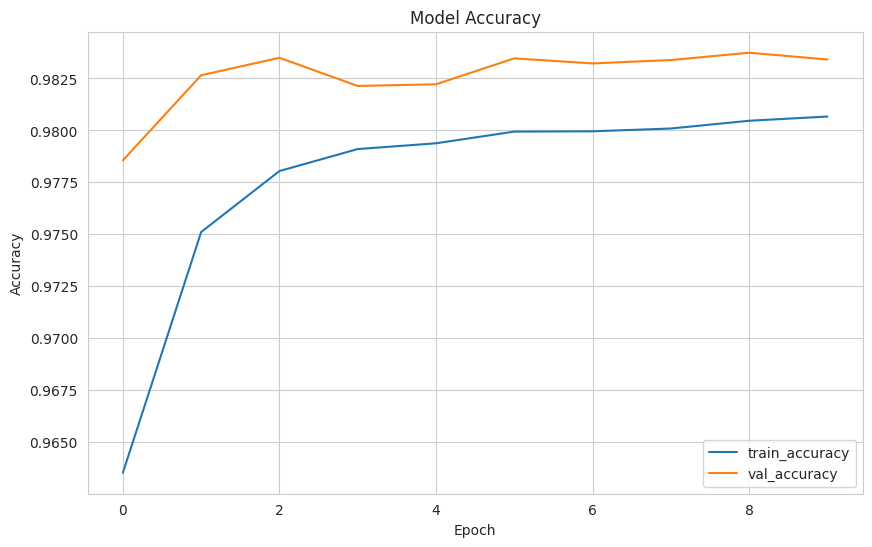

In [64]:
# plot training history
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [65]:
# Predict directly on CIC-IDS2018 holdout set using the model trained only on CIC-IDS2017 (cross-dataset)
nn_pred_cross = (nn_model.predict(X_2018_holdout) > 0.5).astype("int32")
nn_proba_cross = nn_model.predict(X_2018_holdout).ravel()

4143/4143 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
4143/4143 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step


In [66]:
# Evaluate Neural Network cross-dataset performance on CIC-IDS2018
nn_cross_acc = accuracy_score(y_2018_holdout, nn_pred_cross)
nn_cross_prec = precision_score(y_2018_holdout, nn_pred_cross)
nn_cross_rec = recall_score(y_2018_holdout, nn_pred_cross)
nn_cross_f1 = f1_score(y_2018_holdout, nn_pred_cross)
nn_cross_auc = roc_auc_score(y_2018_holdout, nn_proba_cross)

print("Neural Network Cross-Dataset (2018, no fine-tune) - Accuracy:", round(nn_cross_acc, 4))
print("Precision:", round(nn_cross_prec, 4), " Recall:", round(nn_cross_rec, 4),
      " F1:", round(nn_cross_f1, 4), " ROC-AUC:", round(nn_cross_auc, 4))

Neural Network Cross-Dataset (2018, no fine-tune) - Accuracy: 0.7891
Precision: 0.0003  Recall: 0.0  F1: 0.0001  ROC-AUC: 0.8402


In [67]:
# Fine-tune Neural Network on 10% of CIC-IDS2018
# Re-initialize the model to avoid continuing training from a potentially suboptimal state after initial training on CIC-IDS2017
nn_model_finetuned = build_nn_model(X_train_scaled.shape[1])
# Load the weights from the model trained on CIC-IDS2017 to continue training
nn_model_finetuned.set_weights(nn_model.get_weights())

history_finetune = nn_model_finetuned.fit(
    X_2018_finetune, y_2018_finetune, epochs=5, batch_size=32, validation_split=0.2, verbose=0
)

In [68]:
# Predict on the remaining 90% of CIC-IDS2018 after fine-tuning
nn_pred_finetuned = (nn_model_finetuned.predict(X_2018_holdout) > 0.5).astype("int32")
nn_proba_finetuned = nn_model_finetuned.predict(X_2018_holdout).ravel()

4143/4143 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
4143/4143 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step


In [69]:
# Evaluate Neural Network fine-tuned performance on CIC-IDS2018 holdout set
nn_ft_acc = accuracy_score(y_2018_holdout, nn_pred_finetuned)
nn_ft_prec = precision_score(y_2018_holdout, nn_pred_finetuned)
nn_ft_rec = recall_score(y_2018_holdout, nn_pred_finetuned)
nn_ft_f1 = f1_score(y_2018_holdout, nn_pred_finetuned)
nn_ft_auc = roc_auc_score(y_2018_holdout, nn_proba_finetuned)

print("Neural Network Fine-Tuned (2018) - Accuracy:", round(nn_ft_acc, 4))
print("Precision:", round(nn_ft_prec, 4), " Recall:", round(nn_ft_rec, 4),
      " F1:", round(nn_ft_f1, 4), " ROC-AUC:", round(nn_ft_auc, 4))

Neural Network Fine-Tuned (2018) - Accuracy: 0.8599
Precision: 0.5681  Recall: 0.9855  F1: 0.7208  ROC-AUC: 0.9783


## Model Comparison

In [70]:
# Build a comparison table of all models across the three evaluation stages
comparison_data = {
    "Model": ["Random Forest", "Random Forest", "Random Forest",
              "XGBoost", "XGBoost", "XGBoost",
              "Gradient Boosting", "Gradient Boosting", "Gradient Boosting",
              "Neural Network", "Neural Network", "Neural Network"],
    "Stage": ["Baseline (2017)", "Cross-Dataset (2018)", "Fine-Tuned (2018)"] * 4,
    "Accuracy": [rf_baseline_acc, rf_cross_acc, rf_ft_acc,
                 xgb_baseline_acc, xgb_cross_acc, xgb_ft_acc,
                 gb_baseline_acc, gb_cross_acc, gb_ft_acc,
                 nn_cross_acc, nn_cross_acc, nn_ft_acc],
    "Precision": [rf_baseline_prec, rf_cross_prec, rf_ft_prec,
                  xgb_baseline_prec, xgb_cross_prec, xgb_ft_prec,
                  gb_baseline_prec, gb_cross_prec, gb_ft_prec,
                  nn_cross_prec, nn_cross_prec, nn_ft_prec],
    "Recall": [rf_baseline_rec, rf_cross_rec, rf_ft_rec,
               xgb_baseline_rec, xgb_cross_rec, xgb_ft_rec,
               gb_baseline_rec, gb_cross_rec, gb_ft_rec,
               nn_cross_rec, nn_cross_rec, nn_ft_rec],
    "F1-Score": [rf_baseline_f1, rf_cross_f1, rf_ft_f1,
                 xgb_baseline_f1, xgb_cross_f1, xgb_ft_f1,
                 gb_baseline_f1, gb_cross_f1, gb_ft_f1,
                 nn_cross_f1, nn_cross_f1, nn_ft_f1],
    "ROC-AUC": [rf_baseline_auc, rf_cross_auc, rf_ft_auc,
                xgb_baseline_auc, xgb_cross_auc, xgb_ft_auc,
                gb_baseline_auc, gb_cross_auc, gb_ft_auc,
                nn_cross_auc, nn_cross_auc, nn_ft_auc]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.round(4)
display(comparison_df)

,Model,Stage,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,Baseline (2017),0.9966,0.9956,0.9894,0.9925,0.9997
1,Random Forest,Cross-Dataset (2018),0.7839,0.0403,0.0078,0.0130,0.7704
2,Random Forest,Fine-Tuned (2018),0.7926,0.0834,0.0130,0.0225,0.9514
3,XGBoost,Baseline (2017),0.9963,0.9951,0.9886,0.9919,0.9997
4,XGBoost,Cross-Dataset (2018),0.7907,0.0426,0.0065,0.0113,0.8523
5,XGBoost,Fine-Tuned (2018),0.9873,0.9539,0.9781,0.9658,0.9959
6,Gradient Boosting,Baseline (2017),0.9954,0.9934,0.9862,0.9898,0.9995
7,Gradient Boosting,Cross-Dataset (2018),0.7833,0.0339,0.0066,0.0110,0.8599
8,Gradient Boosting,Fine-Tuned (2018),0.9886,0.9553,0.9838,0.9693,0.9963
9,Neural Network,Baseline (2017),0.7891,0.0003,0.0000,0.0001,0.8402


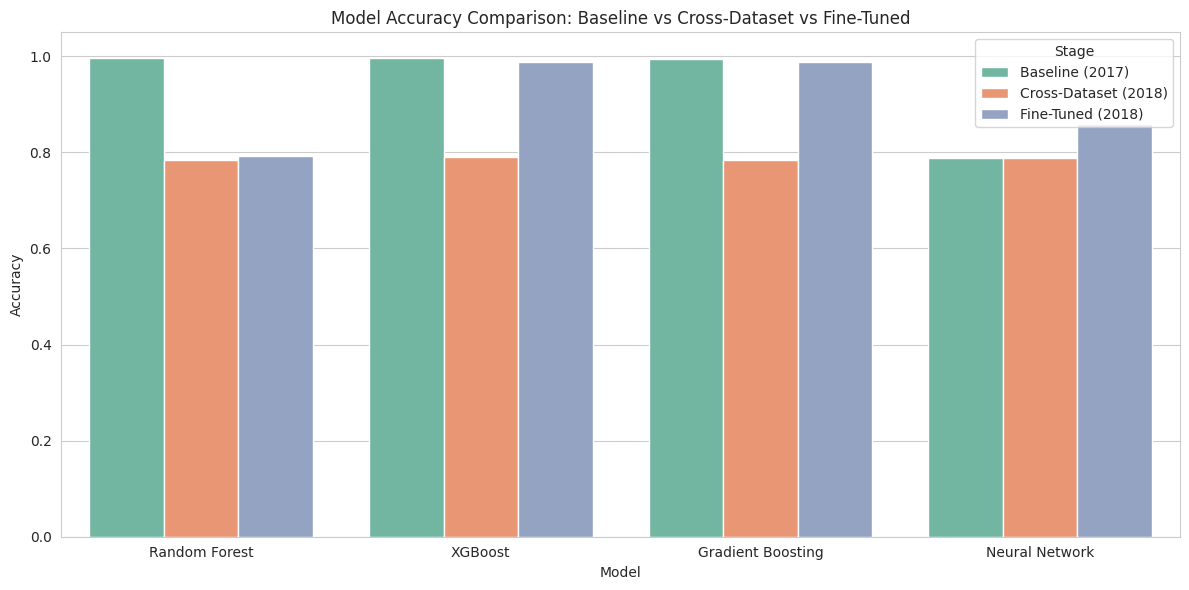

In [71]:
# Graph: Grouped bar chart comparing Accuracy across models and stages
plt.figure(figsize=(12, 6))
sns.barplot(x="Model", y="Accuracy", hue="Stage", data=comparison_df, palette="Set2")
plt.title("Model Accuracy Comparison: Baseline vs Cross-Dataset vs Fine-Tuned")
plt.ylim(0, 1.05)
plt.legend(title="Stage")
plt.tight_layout()
plt.show()

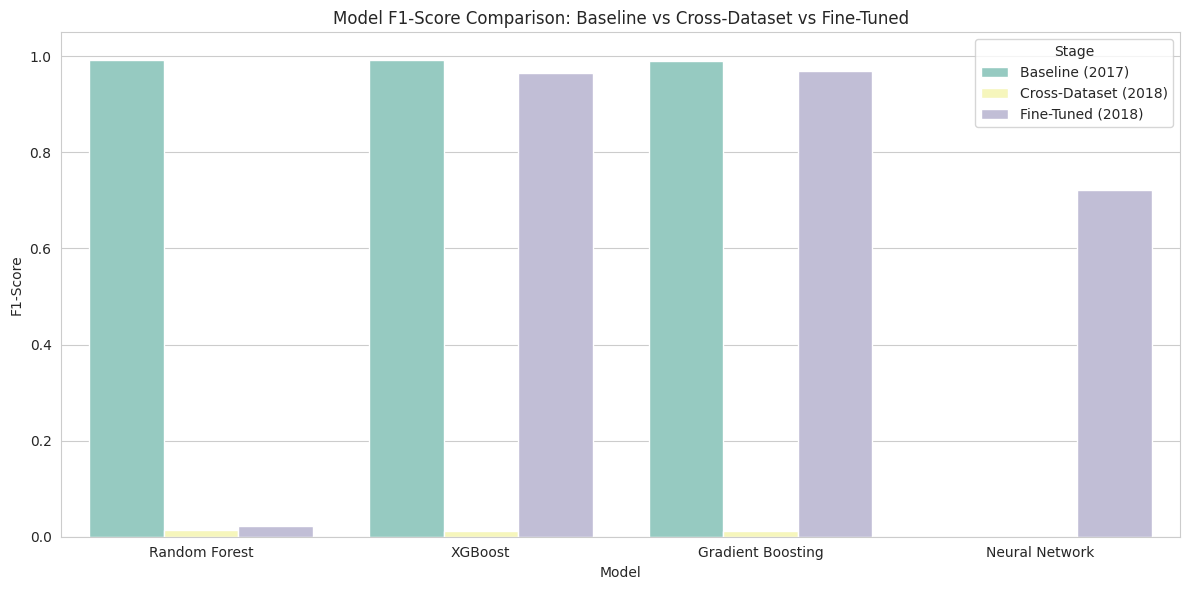

In [72]:
# Graph: Grouped bar chart comparing F1-Score across models and stages
plt.figure(figsize=(12, 6))
sns.barplot(x="Model", y="F1-Score", hue="Stage", data=comparison_df, palette="Set3")
plt.title("Model F1-Score Comparison: Baseline vs Cross-Dataset vs Fine-Tuned")
plt.ylim(0, 1.05)
plt.legend(title="Stage")
plt.tight_layout()
plt.show()

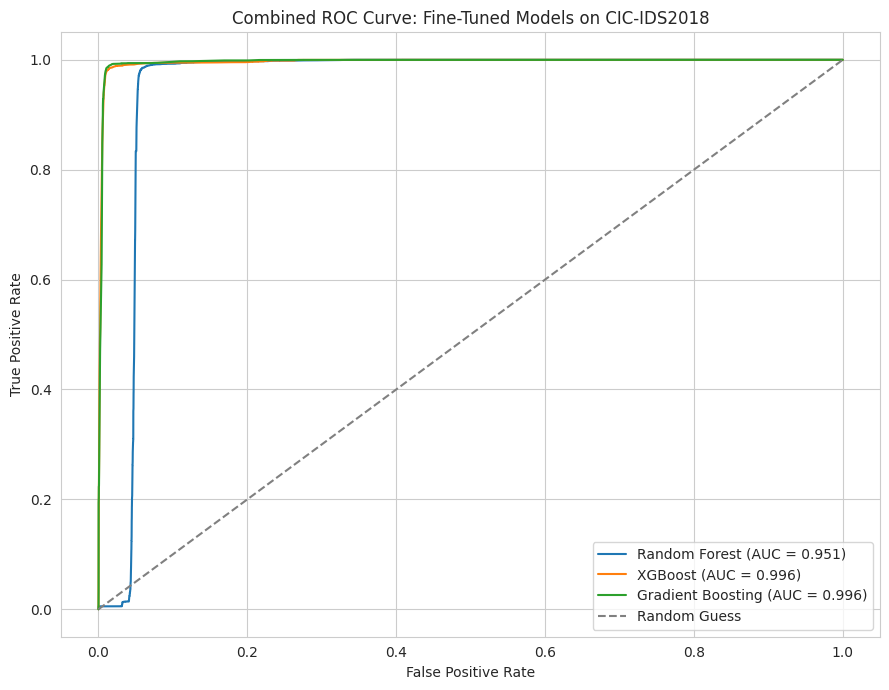

In [73]:
# Combined ROC curve overlay for all models on the CIC-IDS2018 fine-tuned evaluation
fpr_rf, tpr_rf, _ = roc_curve(y_2018_holdout, rf_proba_finetuned)
fpr_xgb, tpr_xgb, _ = roc_curve(y_2018_holdout, xgb_proba_finetuned)
fpr_gb, tpr_gb, _ = roc_curve(y_2018_holdout, gb_proba_finetuned)

plt.figure(figsize=(9, 7))
plt.plot(fpr_rf, tpr_rf, label="Random Forest (AUC = %.3f)" % rf_ft_auc)
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost (AUC = %.3f)" % xgb_ft_auc)
plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting (AUC = %.3f)" % gb_ft_auc)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.title("Combined ROC Curve: Fine-Tuned Models on CIC-IDS2018")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

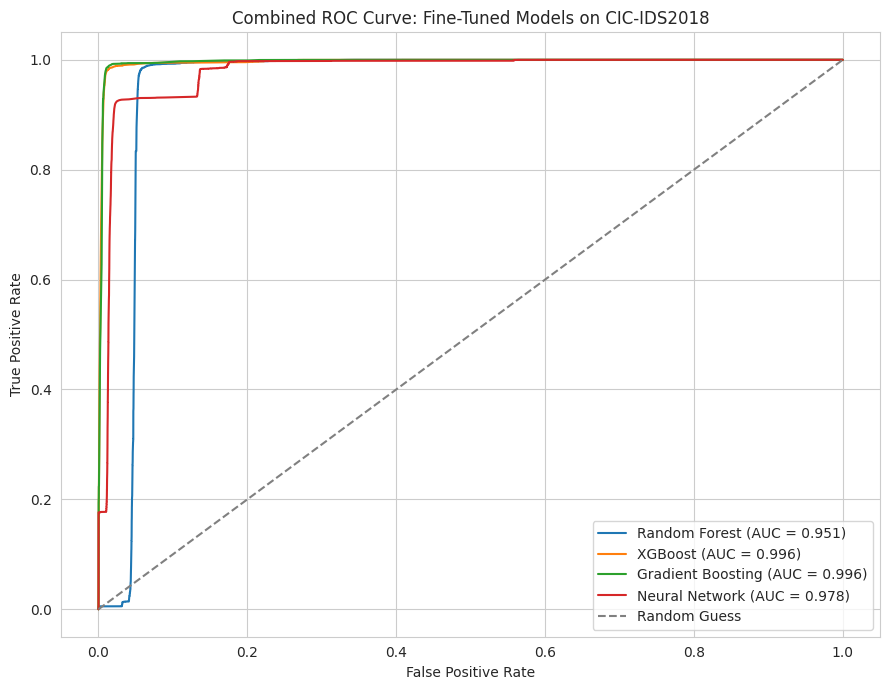

In [74]:
# Combined ROC curve overlay for all models on the CIC-IDS2018 fine-tuned evaluation
fpr_rf, tpr_rf, _ = roc_curve(y_2018_holdout, rf_proba_finetuned)
fpr_xgb, tpr_xgb, _ = roc_curve(y_2018_holdout, xgb_proba_finetuned)
fpr_gb, tpr_gb, _ = roc_curve(y_2018_holdout, gb_proba_finetuned)
fpr_nn, tpr_nn, _ = roc_curve(y_2018_holdout, nn_proba_finetuned)

plt.figure(figsize=(9, 7))
plt.plot(fpr_rf, tpr_rf, label="Random Forest (AUC = %.3f)" % rf_ft_auc)
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost (AUC = %.3f)" % xgb_ft_auc)
plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting (AUC = %.3f)" % gb_ft_auc)
plt.plot(fpr_nn, tpr_nn, label="Neural Network (AUC = %.3f)" % nn_ft_auc)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.title("Combined ROC Curve: Fine-Tuned Models on CIC-IDS2018")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [75]:
# Generalisation gap: how much accuracy drops from 2017 baseline to 2018 cross-dataset
generalisation_gap = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "Gradient Boosting"],
    "Baseline Accuracy (2017)": [rf_baseline_acc, xgb_baseline_acc, gb_baseline_acc],
    "Cross-Dataset Accuracy (2018)": [rf_cross_acc, xgb_cross_acc, gb_cross_acc],
    "Fine-Tuned Accuracy (2018)": [rf_ft_acc, xgb_ft_acc, gb_ft_acc]
})
generalisation_gap["Generalisation Drop"] = (generalisation_gap["Baseline Accuracy (2017)"]
                                              - generalisation_gap["Cross-Dataset Accuracy (2018)"]).round(4)
generalisation_gap["Fine-Tuning Gain"] = (generalisation_gap["Fine-Tuned Accuracy (2018)"]
                                           - generalisation_gap["Cross-Dataset Accuracy (2018)"]).round(4)
generalisation_gap

,Model,Baseline Accuracy (2017),Cross-Dataset Accuracy (2018),Fine-Tuned Accuracy (2018),Generalisation Drop,Fine-Tuning Gain
0,Random Forest,0.996574,0.783948,0.79257,0.2126,0.0086
1,XGBoost,0.996292,0.790707,0.98729,0.2056,0.1966
2,Gradient Boosting,0.995360,0.783337,0.98858,0.2120,0.2052


In [76]:
# Generalisation gap: how much accuracy drops from 2017 baseline to 2018 cross-dataset
generalisation_gap = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "Gradient Boosting", "Neural Network"],
    "Baseline Accuracy (2017)": [rf_baseline_acc, xgb_baseline_acc, gb_baseline_acc, nn_cross_acc], # nn_cross_acc is used here as baseline since NN was trained directly on 2017 and then cross-evaluated
    "Cross-Dataset Accuracy (2018)": [rf_cross_acc, xgb_cross_acc, gb_cross_acc, nn_cross_acc],
    "Fine-Tuned Accuracy (2018)": [rf_ft_acc, xgb_ft_acc, gb_ft_acc, nn_ft_acc]
})
generalisation_gap["Generalisation Drop"] = (generalisation_gap["Baseline Accuracy (2017)"]
                                              - generalisation_gap["Cross-Dataset Accuracy (2018)"]).round(4)
generalisation_gap["Fine-Tuning Gain"] = (generalisation_gap["Fine-Tuned Accuracy (2018)"]
                                           - generalisation_gap["Cross-Dataset Accuracy (2018)"]).round(4)
display(generalisation_gap)

,Model,Baseline Accuracy (2017),Cross-Dataset Accuracy (2018),Fine-Tuned Accuracy (2018),Generalisation Drop,Fine-Tuning Gain
0,Random Forest,0.996574,0.783948,0.792570,0.2126,0.0086
1,XGBoost,0.996292,0.790707,0.987290,0.2056,0.1966
2,Gradient Boosting,0.995360,0.783337,0.988580,0.2120,0.2052
3,Neural Network,0.789085,0.789085,0.859855,0.0000,0.0708
